In [21]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [22]:
load_dotenv()

True

In [23]:
model = ChatMistralAI()

In [24]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [25]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [26]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [27]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

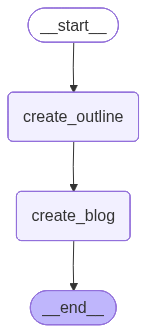

In [28]:
workflow

In [29]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '# **Blog Outline: The Rise of AI in India – Opportunities, Challenges, and the Future**\n\n## **Title:**\n**"AI Revolution in India: How Artificial Intelligence is Reshaping the Nation’s Future"**\n\n## **Introduction**\n- **Hook:** Start with a compelling statistic or example (e.g., "India’s AI market is projected to reach $17 billion by 2027, growing at a CAGR of 25%.")\n- **Brief Overview:** Explain the global AI boom and India’s role in it.\n- **Thesis Statement:** India is rapidly adopting AI across industries, but faces unique challenges while unlocking massive opportunities.\n- **Structure Preview:** Outline what the blog will cover.\n\n---\n\n## **Section 1: The AI Landscape in India – Current Trends & Growth**\n### **1.1 The State of AI Adoption in India**\n- **Market Size & Growth:** CAGR, revenue projections, and key drivers (government initiatives, digital transformation, startup ecosystem).\n- **Global Comparison:** How India st

In [30]:
print(final_state['outline'])

# **Blog Outline: The Rise of AI in India – Opportunities, Challenges, and the Future**

## **Title:**
**"AI Revolution in India: How Artificial Intelligence is Reshaping the Nation’s Future"**

## **Introduction**
- **Hook:** Start with a compelling statistic or example (e.g., "India’s AI market is projected to reach $17 billion by 2027, growing at a CAGR of 25%.")
- **Brief Overview:** Explain the global AI boom and India’s role in it.
- **Thesis Statement:** India is rapidly adopting AI across industries, but faces unique challenges while unlocking massive opportunities.
- **Structure Preview:** Outline what the blog will cover.

---

## **Section 1: The AI Landscape in India – Current Trends & Growth**
### **1.1 The State of AI Adoption in India**
- **Market Size & Growth:** CAGR, revenue projections, and key drivers (government initiatives, digital transformation, startup ecosystem).
- **Global Comparison:** How India stacks up against the US, China, and Europe in AI adoption.
- *

In [31]:
print(final_state['content'])

# **AI Revolution in India: How Artificial Intelligence is Reshaping the Nation’s Future**

## **Introduction**

Imagine a world where a farmer in rural Maharashtra uses AI-powered drones to monitor crop health, a street vendor in Delhi receives a personalized loan offer through an AI-driven fintech app, and a student in Bengaluru learns advanced mathematics from an AI tutor available 24/7. This isn’t science fiction—it’s the reality of India’s AI revolution.

The global artificial intelligence (AI) market is expected to reach **$1.8 trillion by 2030**, and India is emerging as a key player in this transformation. With a **projected AI market size of $17 billion by 2027** (growing at a **25% CAGR**), India is not just adopting AI—it’s redefining how AI can solve some of the country’s most pressing challenges, from healthcare shortages to agricultural inefficiencies.

Yet, this journey is not without hurdles. **Talent shortages, ethical dilemmas, and infrastructure gaps** threaten to sl